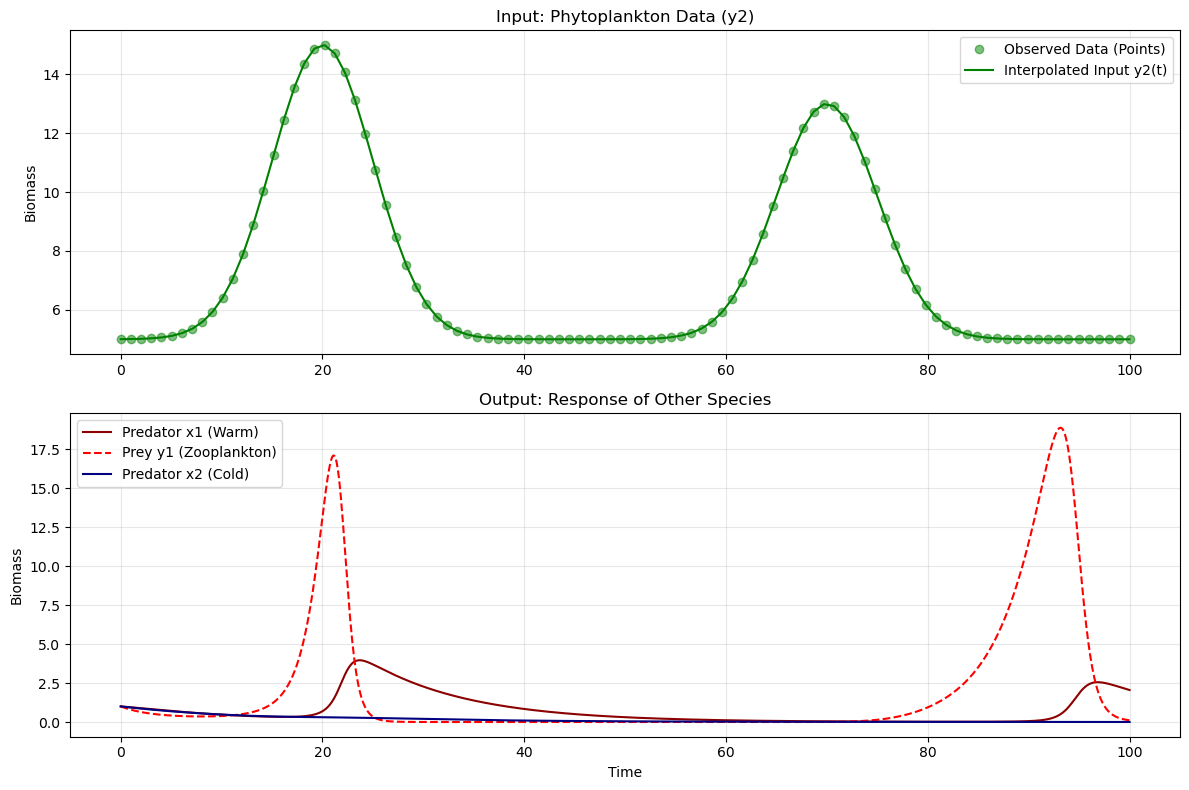

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from scipy.interpolate import interp1d

# -------------------------------------------------------
# 1. 既知データの準備 (本来はここでお持ちのCSVなどを読み込みます)
# -------------------------------------------------------
# 例として、季節変動する植物プランクトンデータを作成します
t_data = np.linspace(0, 100, 100)  # データの時間点
# y2データ: 春(t=20付近)と秋(t=70付近)にブルームするようなデータ
y2_data = 5.0 + 10.0 * np.exp(-(t_data - 20)**2 / 50) + 8.0 * np.exp(-(t_data - 70)**2 / 50)

# ★重要: 離散データを「関数」にする (線形補間)
# これで y2_func(3.5) のように好きな時間の値を取得できます
y2_func = interp1d(t_data, y2_data, kind='linear', bounds_error=False, fill_value="extrapolate")

# -------------------------------------------------------
# 2. モデルの定義 (y2 は計算対象外)
# -------------------------------------------------------
def forced_ecosystem_model(state, t, params):
    # 変数の展開 (y2 はここにはいない)
    x1, y1, x2 = state
    
    # 現在の y2 の値をデータから取得
    current_y2 = y2_func(t)
    
    # パラメータ
    r_x1, r_x2 = params['r_x']
    c1 = params['c1']
    d2 = params['d2']
    lam11 = params['lambda_11']
    lam21 = params['lambda_21']
    lam22 = params['lambda_22']
    
    # 画像の数式にある r_y2(t) 係数
    # (モデルの構造上、y1の増加項にかかっている係数)
    r_y2_param = 1.0 

    # 微分方程式 (y2 の式は不要なので削除)
    
    # dx1/dt: 暖水系捕食者
    dx1dt = -r_x1 * x1 + c1 * lam11 * x1 * y1
    
    # dy1/dt: 暖水系Prey
    # ここで変数としてのy2ではなく、データから得た current_y2 を使います
    dy1dt = r_y2_param * lam21 * y1 * current_y2 - lam11 * x1 * y1
    
    # dx2/dt: 冷水系捕食者
    # ここも current_y2 を使います
    dx2dt = -r_x2 * x2 + d2 * lam22 * x2 * current_y2
    
    return [dx1dt, dy1dt, dx2dt]

# -------------------------------------------------------
# 3. 計算実行
# -------------------------------------------------------
params = {
    'r_x': [0.1, 0.1],
    'c1': 0.1,
    'd2': 0.1,
    'lambda_11': 0.5,
    'lambda_21': 0.05, # y2の値がデータ由来で大きくなる可能性があるので少し小さめに調整
    'lambda_22': 0.05
}

# 初期状態 (x1, y1, x2 の3つだけ)
initial_state = [1.0, 1.0, 1.0]

# シミュレーション用時間 (データの範囲内にするのが無難)
t_sim = np.linspace(0, 100, 1000)

solution = odeint(forced_ecosystem_model, initial_state, t_sim, args=(params,))

# -------------------------------------------------------
# 4. 可視化
# -------------------------------------------------------
x1_sol = solution[:, 0]
y1_sol = solution[:, 1]
x2_sol = solution[:, 2]
y2_input = y2_func(t_sim) # 入力データもプロット用に取得

plt.figure(figsize=(12, 8))

# 上段: 入力データ (植物プランクトン)
plt.subplot(2, 1, 1)
plt.plot(t_data, y2_data, 'o', label='Observed Data (Points)', color='green', alpha=0.5)
plt.plot(t_sim, y2_input, '-', label='Interpolated Input y2(t)', color='green')
plt.title('Input: Phytoplankton Data (y2)')
plt.ylabel('Biomass')
plt.legend()
plt.grid(True, alpha=0.3)

# 下段: 推定結果 (その他の生物)
plt.subplot(2, 1, 2)
plt.plot(t_sim, x1_sol, label='Predator x1 (Warm)', color='darkred')
plt.plot(t_sim, y1_sol, label='Prey y1 (Zooplankton)', color='red', linestyle='--')
plt.plot(t_sim, x2_sol, label='Predator x2 (Cold)', color='navy')

plt.title('Output: Response of Other Species')
plt.xlabel('Time')
plt.ylabel('Biomass')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Time shape: (270,)
Data shape: (270,)


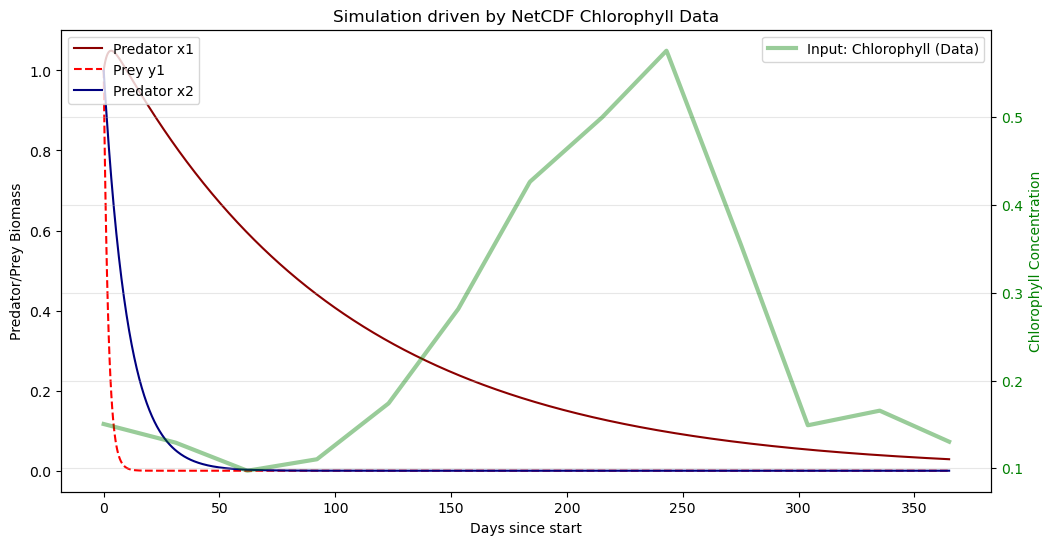

In [32]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
from scipy.integrate import odeint
from scipy.interpolate import interp1d

# -------------------------------------------------------
# 1. NetCDFデータの読み込みと加工
# -------------------------------------------------------
# ※ファイルパスは実際のファイル名に変更してください
ds = xr.open_dataset('cmems_mod_glo_bgc_my_0-Copy1.25deg_P1M-m_1763298608482.nc')


# --- ここからが実際の処理手順です ---

# (A) 特定の海域を切り出して平均する
# latitude, longitude に直します
target_area = ds['chl'].sel(latitude=slice(30, 33), longitude=slice(135, 138))

# ★修正ポイント1: ここで mean を計算した後、余計な次元(depthなど)を圧縮します
chl_timeseries = target_area.mean(dim=['latitude', 'longitude']).squeeze()

# (B) 欠損値(NaN)の処理
chl_timeseries = chl_timeseries.interpolate_na(dim='time', method='linear')

# (C) 時間を「数値(経過日数)」に変換する
time_values = chl_timeseries['time'].values
days_numeric = (time_values - time_values[0]) / np.timedelta64(1, 'D')
chl_values = chl_timeseries.values

# 確認用プリント: これで (N,) という形になっていればOKです
print("Time shape:", days_numeric.shape)
print("Data shape:", chl_values.shape)

# (D) 補間関数の作成
y2_func = interp1d(days_numeric, chl_values, kind='linear', fill_value="extrapolate")
# -------------------------------------------------------
# 2. モデルの定義 (y2 = クロロフィルデータを外部入力)
# -------------------------------------------------------
def forced_ecosystem_model(state, t, params):
    x1, y1, x2 = state # y2(植物プランクトン)は変数に含まない
    
    # 時刻 t におけるクロロフィル濃度をデータから取得
    # ※マイナスになったりしないよう、念のため max(0, ...) を入れます
    current_chl = max(0, y2_func(t))
    
    # パラメータ展開
    r_x1, r_x2 = params['r_x']
    c1 = params['c1']
    d2 = params['d2']
    lam11 = params['lambda_11']
    lam21 = params['lambda_21']
    lam22 = params['lambda_22']
    
    # 数式 (y2 の部分を current_chl に置き換え)
    
    # dx1/dt (暖水系捕食者)
    dx1dt = -r_x1 * x1 + c1 * lam11 * x1 * y1
    
    # dy1/dt (動物プランクトン的なPrey)
    # クロロフィル(current_chl)を食べて増える
    dy1dt = 1.0 * lam21 * y1 * current_chl - lam11 * x1 * y1
    
    # dx2/dt (冷水系捕食者)
    # クロロフィル(current_chl)を食べて増える(と仮定する場合)
    dx2dt = -r_x2 * x2 + d2 * lam22 * x2 * current_chl
    
    return [dx1dt, dy1dt, dx2dt]


# -------------------------------------------------------
# 3. シミュレーション実行
# -------------------------------------------------------
params = {
    'r_x': [0.01, 0.01],
    'c1': 0.1, 'd2': 0.1,
    'lambda_11': 0.5, 'lambda_21': 0.1, 'lambda_22': 0.3
}

# 初期値 [x1, y1, x2]
initial_state = [1.0, 1.0, 1.0]

# シミュレーション時間
# データの期間に合わせて設定 (ここでは0日目から365日目まで)
t_sim = np.linspace(0, 365, 1000)

solution = odeint(forced_ecosystem_model, initial_state, t_sim, args=(params,))


# -------------------------------------------------------
# 4. 結果の可視化
# -------------------------------------------------------
x1_sol = solution[:, 0]
y1_sol = solution[:, 1]
x2_sol = solution[:, 2]
input_chl = y2_func(t_sim) # グラフ用に補間データを取得

fig, ax1 = plt.subplots(figsize=(12, 6))

# 左軸: 生物量
ax1.plot(t_sim, x1_sol, label='Predator x1', color='darkred')
ax1.plot(t_sim, y1_sol, label='Prey y1 ', color='red', linestyle='--')
ax1.plot(t_sim, x2_sol, label='Predator x2', color='navy')
ax1.set_xlabel('Days since start')
ax1.set_ylabel('Predator/Prey Biomass')
ax1.legend(loc='upper left')

# 右軸: クロロフィルデータ (入力)
ax2 = ax1.twinx()
ax2.plot(t_sim, input_chl, label='Input: Chlorophyll (Data)', color='green', alpha=0.4, linewidth=3)
ax2.set_ylabel('Chlorophyll Concentration', color='green')
ax2.tick_params(axis='y', labelcolor='green')
ax2.legend(loc='upper right')

plt.title('Simulation driven by NetCDF Chlorophyll Data')
plt.grid(True, alpha=0.3)
plt.show()